<a href="https://colab.research.google.com/github/vastav03/Machine-Learning-Practical/blob/main/Linear%20Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np  # numeric arrays & random data
import pandas as pd  # organise data into a table
import matplotlib.pyplot as plt  # plot graphs
from sklearn.model_selection import train_test_split
    # split data
from sklearn.linear_model import LinearRegression
    # the model class
from sklearn.metrics import mean_squared_error, r2_score
    # evaluation


In [ ]:
np.random.seed(42)  # fixes randomness so results repeat
years_exp = np.random.uniform(0, 10, 40)
    # 40 values, 0-10 years
salary = 3.0 + 1.8 * years_exp + np.random.normal(0, 1.2, 40)
    # salary(LPA) = base 3 + 1.8/year + random noise
df = pd.DataFrame({'YearsExperience': years_exp, 'Salary_LPA': salary})
    # combine both columns into one table
df.head()  # show first 5 rows to check the data


,YearsExperience,Salary_LPA
0,3.745401,9.725525
1,9.507143,18.843604
2,7.319939,17.162945
3,5.986585,12.310840
4,1.560186,6.058972


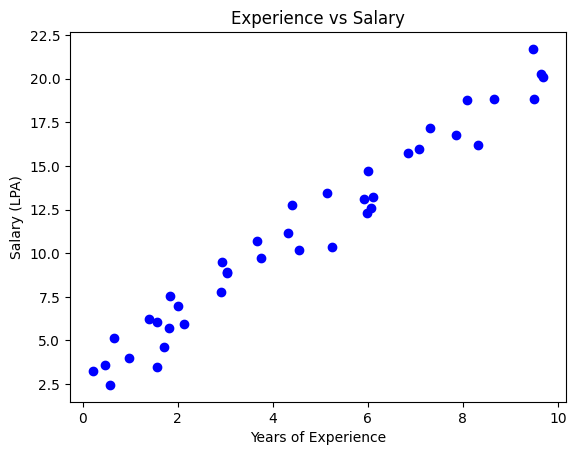

In [ ]:
plt.scatter(df['YearsExperience'], df['Salary_LPA'], color='blue')
    # experience (X) vs salary (Y)
plt.xlabel('Years of Experience')  # label the X-axis
plt.ylabel('Salary (LPA)')  # label the Y-axis
plt.title('Experience vs Salary')  # title of the plot
plt.show()  # display the plot


In [ ]:
X = df[['YearsExperience']]
    # input feature; 2-D, so double brackets
y = df['Salary_LPA']  # output/target variable (1-D)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
    # 80% train, 20% test


In [ ]:
model = LinearRegression()  # create an untrained model object
model.fit(X_train, y_train)
    # train it: m and c get calculated here
print('Slope (m):', model.coef_[0])  # the learned slope
print('Intercept (c):', model.intercept_)
    # the learned intercept


Slope (m): 1.853979373596087
Intercept (c): 2.6027307485710995


In [ ]:
y_pred = model.predict(X_test)
    # predict salary for unseen test data
mse = mean_squared_error(y_test, y_pred)  # avg squared error
r2 = r2_score(y_test, y_pred)
    # how well the line fits (0 to 1)
print('Mean Squared Error:', mse)
print('R-squared Score:', r2)


Mean Squared Error: 1.1119214249844693
R-squared Score: 0.921153583350151


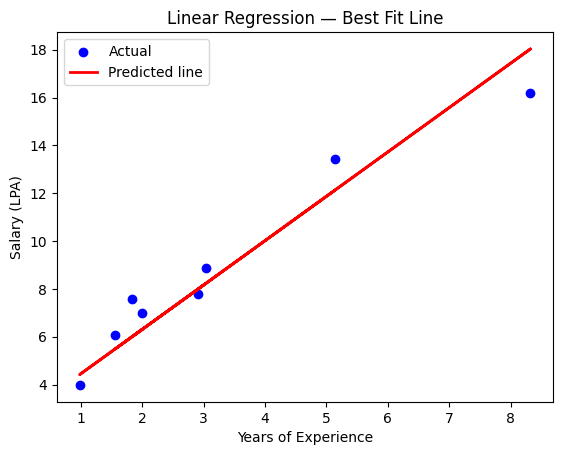

In [ ]:
plt.scatter(X_test, y_test, color='blue', label='Actual')
    # actual points
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted line')
    # the model's best-fit line
plt.xlabel('Years of Experience')
plt.ylabel('Salary (LPA)')
plt.title('Linear Regression — Best Fit Line')
plt.legend()  # show the Actual/Predicted labels
plt.show()


In [ ]:
new_experience = [[5]]  # a candidate with 5 years experience
predicted_salary = model.predict(new_experience)
print('Predicted salary for 5 years experience:', predicted_salary[0], 'LPA')


Predicted salary for 5 years experience: 11.872627616551535 LPA


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
